# Task 4: Classification with Logistic Regression

## Objective
Build a binary classification model using Logistic Regression to classify breast cancer tumors as Malignant or Benign.

**Dataset:** Breast Cancer Wisconsin Dataset

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)

## Step 1: Import Required Libraries

In this step, we import all the libraries required for data manipulation, visualization, model training, and evaluation.

In [3]:
df = pd.read_csv("breast_cancer.csv")

## Step 3: Explore the Dataset

Check the structure of the dataset using head(), shape, info(), and describe().

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.shape

(569, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## Step 4: Check Missing Values

Identify missing values and remove unnecessary columns if required.

In [7]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

## Step 5: Data Preprocessing

- Remove unnecessary columns.
- Convert categorical target values into numerical values.

In [8]:
df.drop(columns=["Unnamed: 32", "id"], inplace=True)

In [9]:
df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})


In [10]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 6: Separate Features and Target

Split the dataset into input features (X) and target variable (y).

In [11]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

## Step 7: Train-Test Split

Split the dataset into training and testing sets using an 80:20 ratio.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 8: Feature Scaling

Standardize the feature values using StandardScaler to improve model performance.


In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Step 9: Train Logistic Regression Model

Train the Logistic Regression classifier using the training dataset.

In [15]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Step 10: Make Predictions

Predict the class labels and prediction probabilities for the test dataset.

In [16]:
y_pred = model.predict(X_test)

In [17]:
y_prob = model.predict_proba(X_test)[:,1]

In [18]:
print(model.score(X_test, y_test))

0.9736842105263158


## Step 11: Confusion Matrix

Visualize the model's prediction performance using a confusion matrix.

In [19]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[70  1]
 [ 2 41]]


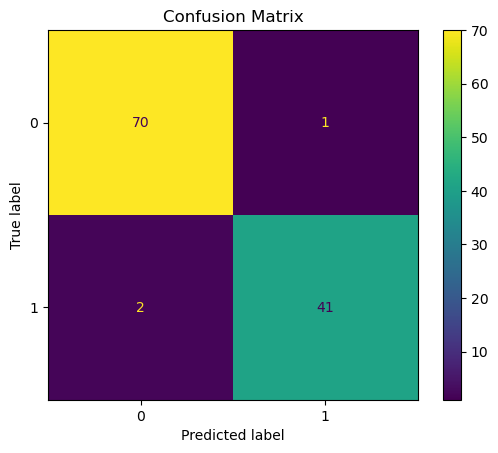

In [20]:
disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.title("Confusion Matrix")

plt.savefig("images/confusion_matrix.png")

plt.show()

## Step 12: Classification Report

Evaluate the model using Precision, Recall, F1-score, and Accuracy.

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Step 13: Precision and Recall

Calculate Precision and Recall to measure the classification performance.

In [25]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9761904761904762


In [26]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)


Recall: 0.9534883720930233


## Step 14: ROC Curve

Plot the Receiver Operating Characteristic (ROC) Curve to evaluate the classifier.

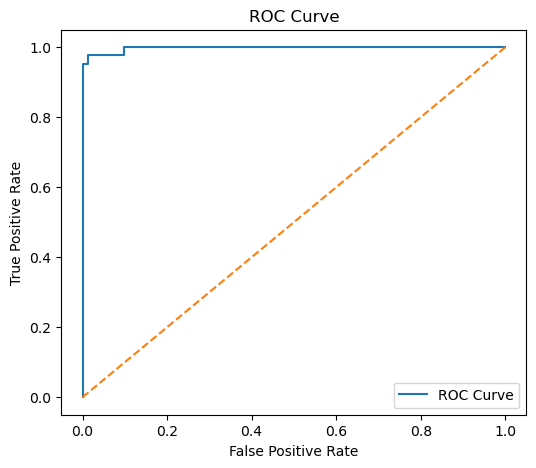

In [27]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("images/roc_curve.png")

plt.show()

## Step 15: ROC-AUC Score

Calculate the Area Under the ROC Curve (AUC) to measure the model's overall performance.

In [28]:
auc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", auc)

ROC AUC Score: 0.99737962659679


## Step 16: Threshold Tuning

Modify the decision threshold and observe how Precision and Recall change.

In [29]:
new_prediction = (y_prob >= 0.3).astype(int)

print(new_prediction)

[0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1]


## Step 17: Sigmoid Function

Visualize the Sigmoid Function used by Logistic Regression to convert outputs into probabilities.

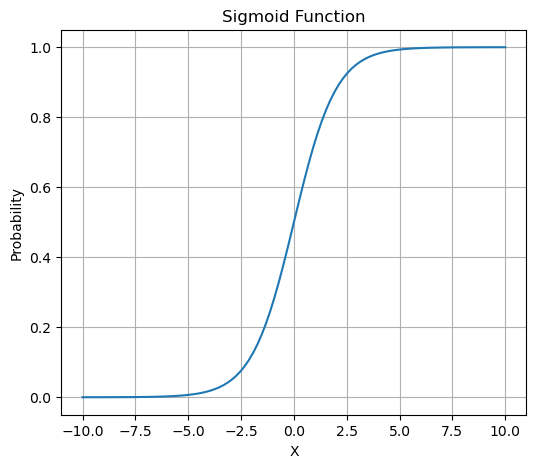

In [30]:
x = np.linspace(-10,10,100)

y = 1/(1+np.exp(-x))

plt.figure(figsize=(6,5))

plt.plot(x,y)

plt.title("Sigmoid Function")

plt.xlabel("X")

plt.ylabel("Probability")

plt.grid(True)

plt.savefig("images/sigmoid_curve.png")

plt.show()

# Conclusion

In this project, a Logistic Regression model was successfully developed to classify breast cancer tumors as Malignant or Benign.

The dataset was preprocessed by removing unnecessary columns, converting the target variable into numerical format, and standardizing the features.

The trained model achieved high accuracy and performed well across evaluation metrics such as Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC Score.

The ROC Curve and Sigmoid Function helped visualize the classifier's performance and probability estimation.

Overall, Logistic Regression proved to be an effective and reliable algorithm for binary classification on the Breast Cancer Wisconsin Dataset.